# LDA :Latent Dirichlet Allocation. It is a technique used in NLP to automatically find hidden topics inside many documents. LSA : Latent Semantic Analysis. It is an NLP technique used to find hidden relationships and topics in text data.

In [1]:
import pandas as pd
# Import pandas library for handling tables and datasets

import re
# Import regular expression module for text cleaning and pattern matching

from nltk.corpus import stopwords
# Import stopwords list from NLTK
# Stopwords are common words like "is", "the", "and"

from nltk.tokenize import word_tokenize
# Import word_tokenize function to split sentences into words

from nltk.stem import PorterStemmer
# Import PorterStemmer for stemming words
# Example: playing → play, booked → book

from gensim.models import LsiModel

import gensim
# Import gensim library used for NLP tasks like topic modeling

import gensim.corpora as corpora
# Import corpora module from gensim
# Used to create dictionary and document-term matrix for LDA topic modeling

from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

### Load Data

In [2]:
data = pd.read_csv("news_articles.csv") 

In [3]:
data.head()

,id,title,content
0,25626,"One Weight-Loss Approach Fits All? No, Not Eve...","Dr. Frank Sacks, a professor of nutrition at H..."
1,19551,South Carolina Stuns Baylor to Reach the Round...,South Carolina’s win over Duke was not only ...
2,25221,"U.S. Presidential Race, Apple, Gene Wilder: Yo...",(Want to get this briefing by email? Here’s th...
3,18026,"His Predecessor Gone, Gambia’s New President F...","BANJUL, Gambia — A week after he was inaugu..."
4,21063,‘Harry Potter and the Cursed Child’ Goes From ...,The biggest book of the summer isn’t a blockbu...


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       100 non-null    int64 
 1   title    100 non-null    object
 2   content  100 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.5+ KB


### Clean Data

In [5]:
# take just the content of the article, lowercase and remove punctuation
# articles = data['content'].str.lower().apply(lambda x: re.sub(r"([^\w\s])", "", x))
articles = data['content'].str.lower()
# .str.lower() => automatically goes through every row in the column.
# o/p: 0     dr. frank sacks, a professor of nutrition at h...


articles = articles.apply(
    lambda x: re.sub(r"([^\w\s])", "", x)
)
# re.sub => Custom Python Function. Pandas cannot automatically apply it.
# .apply() => need to go through every row in the column.
# Apply a regex cleaning function to every sentence and remove punctuation/special characters.
# print(articles)
# o/p: 0     dr frank sacks a professor of nutrition at har...


en_stopwords = stopwords.words('english')
articles = articles.apply(
    lambda x: ' '.join(
        [word for word in x.split() if word not in en_stopwords]
    )
)
# We use ' '.join() to convert the filtered list of words back into a normal sentence/string after removing stopwords.
# print(articles)
# o/p: 0     dr frank sacks professor nutrition harvard lik...


# tokenize
articles = articles.apply(lambda x: word_tokenize(x))
# Before tokenize: "machine learning is amazing"
# After tokenize: ['machine', 'learning', 'is', 'amazing']
# It breaks a sentence into words.
# print(articles)
# o/p: 0     [dr, frank, sacks, professor, nutrition, harva...

# stemming (done for speed as we have a lot of text)
ps = PorterStemmer()
articles = articles.apply(lambda tokens: [ps.stem(token) for token in tokens])
# [] => Create a new list containing all stemmed words.
# print(articles)
# o/p: 0     [dr, frank, sack, professor, nutrit, harvard, ...


# The tokenized output is already a list, but we use [] again to create a new list containing the transformed (stemmed) words.

In [6]:
articles

0     [dr, frank, sack, professor, nutrit, harvard, ...
1     [south, carolina, win, duke, surpris, fan, pos...
2     [want, get, brief, email, here, good, even, he...
3     [banjul, gambia, week, inaugur, anoth, countri...
4     [biggest, book, summer, isnt, blockbust, thril...
                            ...                        
95    [want, get, brief, email, here, good, even, he...
96    [tallinn, estonia, guard, brought, ahm, abdul,...
97    [gov, scott, walker, wisconsin, activ, wiscons...
98    [social, media, shook, emot, headlin, shout, n...
99    [moment, joanna, acevedo, first, set, foot, bo...
Name: content, Length: 100, dtype: object

### Vectorization

In [7]:
# create dictionary of all words
dictionary = corpora.Dictionary(articles)
print(dictionary)

# Finds unique words
# Gives each word an ID
# Example:
    # {
    #     'ai': 0,
    #     'machine': 1,
    #     'learning': 2,
    #     'python': 3,
    #     'football': 4,
    #     'goal': 5
    # }

Dictionary<8693 unique tokens: ['10', '100', '108', '15', '155']...>


In [8]:
# vecotize using bag of words into a document term matrix
doc_term = [dictionary.doc2bow(text) for text in articles]
# print(doc_term)
# Convert every document into a Bag of Words numerical format using word IDs and word counts.
# doc2bow() takes a single article, looks up each word in the dictionary,and
# returns a list of word IDs together with their counts
# Example:
    # Dictionary
        # {
        #  'ai': 0,
        #  'machine': 1,
        #  'learning': 2,
        #  'python': 3
        # }
    # What doc2bow() Does
        # dictionary.doc2bow(text)
        # (word_id, word_count)
    # Document 1:
        # ['ai', 'machine', 'learning']
        # Conversion
        # | Word     | ID | Count |
        # | -------- | -- | ----- |
        # | ai       | 0  | 1     |
        # | machine  | 1  | 1     |
        # | learning | 2  | 1     |
    # o/p:
        # [(0,1), (1,1), (2,1)]
        

In [9]:
# print(doc_term)

### LDA

In [10]:
# specify number of topics
num_topics = 2
# Tell the model to find 2 hidden topics.

In [11]:
# create LDA model
lda_model = gensim.models.LdaModel(corpus=doc_term,
                                   id2word=dictionary,
                                   num_topics=num_topics)

print(lda_model)

LdaModel<num_terms=8693, num_topics=2, decay=0.5, chunksize=2000>


In [12]:
lda_model.print_topics(num_topics=num_topics, num_words=5)

[(0,
  '0.017*"said" + 0.014*"mr" + 0.005*"would" + 0.005*"trump" + 0.004*"one"'),
 (1,
  '0.020*"mr" + 0.013*"said" + 0.006*"trump" + 0.004*"state" + 0.004*"year"')]

In [13]:
# In LDA, the model does NOT automatically give topic names.
# It only gives the most important words for each topic.

# LdaModel<num_terms=8693, num_topics=2, decay=0.5, chunksize=2000> => = Summary of an LDA topic model showing vocabulary size, number of topics, learning decay rate, and batch processing size.

In [14]:
lsamodel = LsiModel(
    doc_term,
    num_topics=num_topics,
    id2word=dictionary
)


In [15]:
print(lsamodel.print_topics(num_topics=num_topics, num_words=5))

[(0, '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would"'), (1, '-0.537*"mr" + -0.319*"trump" + 0.286*"said" + 0.242*"saudi" + 0.142*"weight"')]


# Determine Number of Topics

In [17]:
# generate coherence scores to determine an optimum number of topics
coherence_values = []
model_list = []
# Two empty lists are created.

# coherence_values:
    # coherence_values is a list that stores the coherence score of every topic model.
    # How good or meaningful are the topics generated by the model?

# model_list: 
    # This stores all generated LSI models.

min_topics = 2
max_topics = 11
# This means:
    # Start testing from 2 topics
    # End at 11 topics


for num_topics_i in range(min_topics, max_topics+1):
    # 2 → 3 → 4 → ... → 11
    
    model = LsiModel(doc_term, num_topics=num_topics_i, id2word = dictionary, random_seed=0)
    # doc_term:
        # This is the document-term matrix (Bag of Words or TF-IDF).
        # | Word   | Count |
        # | ------ | ----- |
        # | ai     | 3     |
        # | python | 2     |
    # Controls how many topics the model should find.
    # id2word=dictionary
        # Maps word IDs back to real words.
        # 0 → python
        # 1 → ai
        # 2 → data
    # random_seed=0
        # When computers train models, they often use random starting points internally.
        # So every time you run the code, the model may produce slightly different topics.
        # Without random_seed
            # First run
                # Topic 1 → python, coding, developer
                # Topic 2 → ai, machine, learning
            # Second run
                # Topic 1 → developer, software, java
                # Topic 2 → learning, neural, ai
        # with random_seed=0
            # First run
                # Topic 1 → python, coding, developer
                # Topic 2 → ai, machine, learning
            # Second run
                # Topic 1 → python, coding, developer
                # Topic 2 → ai, machine, learning
    model_list.append(model)
    # The created model is saved into the list.
    # model_list = [model_2, model_3, model_4, ...]
    
    coherence_model = CoherenceModel(model=model, texts=articles, dictionary=dictionary, coherence='c_v')
    # What is Coherence?
        # Do the topic words make sense together?
        # ["python", "java", "coding", "developer"] => Good
        # ["apple", "car", "doctor", "football"] => Bad
    # model=model: 
        # The LSI model to evaluate.
    # texts=articles
        # articles = [
        #     ['python', 'easy', 'programming'],
        #     ['machine', 'learning', 'ai'],
        #     ['football', 'team', 'match']
        #           ]
        # Each inner list = one document/article.
    # dictionary=dictionary: 
        # Word-ID mapping.
    # coherence='c_v': 
        # c_v is the most commonly used coherence score because it matches human understanding well.
    
    coherence_values.append(coherence_model.get_coherence())
        # Calculates the coherence score.
        # coherence_values = [0.42, 0.48, 0.59, 0.63, 0.57]
                            # 2 topics → 0.42
                            # 3 topics → 0.48
                            # 4 topics → 0.59
                            # 5 topics → 0.63
                            # 6 topics → 0.57
                            # Best number of topics = 5

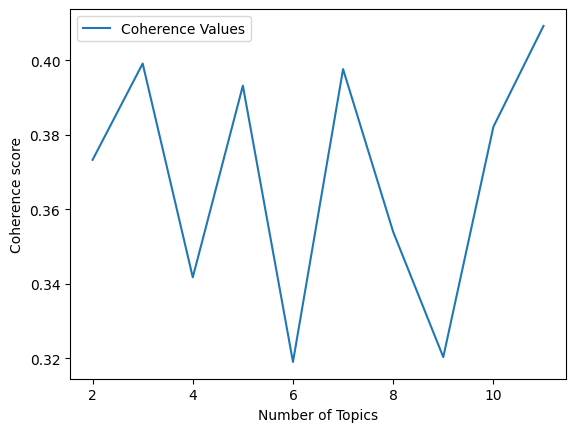

In [19]:
# This code is used to draw a graph of:
# Number of Topics vs Coherence Score
# so you can visually find the best topic number.

plt.plot(range(min_topics, max_topics+1), coherence_values)
# This draws the line graph.
# range(min_topics, max_topics+1): X-axis Values
                                  # min_topics = 2
                                  # max_topics = 11
# coherence_values: Y-axis Values
                                 # [0.41, 0.52, 0.60, 0.63, 0.58]
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")

plt.legend(["Coherence Values"], loc='best')
# Legend means small label box inside graph.

plt.show()

In [21]:
final_n_topics = 3
# We decided the best number of topics is 3.

lsamodel_f = LsiModel(
    doc_term,
    num_topics=final_n_topics,
    id2word=dictionary
)

# doc_term: This is the document-term matrix. [(0,2), (1,3)]
# id2word=dictionary: Converts word IDs back into real words.
            # 0 → python
            # 1 → ai
            # 2 → data

print(lsamodel_f.print_topics(num_topics=final_n_topics, num_words=5))


# num_words=5
    # For each topic:
    # Show top 5 important words.

[(0, '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would"'), (1, '-0.537*"mr" + -0.319*"trump" + 0.286*"said" + 0.242*"saudi" + 0.142*"weight"'), (2, '0.460*"saudi" + 0.264*"taliban" + -0.249*"weight" + 0.194*"afghanistan" + -0.191*"dr"')]


In [ ]:
# [
# (0, '0.615*"mr" + 0.429*"said" + 0.187*"trump" + 0.130*"state" + 0.119*"would"'),

# (1, '-0.537*"mr" + -0.319*"trump" + 0.286*"said" + 0.242*"saudi" + 0.142*"weight"'),

# (2, '0.460*"saudi" + 0.264*"taliban" + -0.249*"weight" + 0.194*"afghanistan" + -0.191*"dr"')
# ]


# (topic_number, topic_words_with_weights)

# Your LSI model discovered 3 hidden topics and showed the most important words with their weights for each topic.